# 01 — Data Exploration

Understanding the raw signal

**This notebook:**
- Loads REFIT House 1 low-frequency data
- Plots aggregate mains over time
- Plots individual appliance traces
- Checks data quality: gaps, nulls, sampling regularity

**Why this matters:**
Before working with NILM data, I assumed that feature engineering would be the most important part of the pipeline. After examining the raw signals, I realized that understanding the signal characteristics is equally important because feature selection depends heavily on the underlying electrical behavior.

In [5]:
import sys
import os
sys.path.append('..')
sys.path.append(os.path.join('..', 'utils'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from utils.signal_utils import load_refit_house

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

## Load the data

REFIT House 1 contains aggregate household power measurements together with appliance-level ground truth readings. In this project, the aggregate mains signal represents what a single electricity meter would observe, while the appliance channels help verify which devices were active at a given time.

### Initial Thoughts
One thing that immediately stood out to me was the size of the dataset. With more than 55 million samples collected over nearly two years, even simple visual exploration can reveal long-term appliance usage patterns that would be impossible to notice in a short laboratory experiment.

In [ ]:
from utils.signal_utils import load_refit_house

HOUSE_FILE = r'C:\Users\mkpad\OneDrive\Desktop\load-fingerprinting\data\raw\House1.csv'

df, labels = load_refit_house(HOUSE_FILE)

print('Shape:', df.shape)
print('Date range:', df.index[0], 'to', df.index[-1])
print('Appliances:', [c for c in df.columns if c != 'mains'])
df.head()

Shape: (55201816, 9)
Date range: 2013-10-09 13:06:17 to 2015-07-10 10:56:32
Appliances: ['Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8']


,mains,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8
Time,,,,,,,,,
2013-10-09 13:06:17,523.0,74.0,0.0,69.0,0.0,0.0,0.0,0.0,0.0
2013-10-09 13:06:18,523.0,74.0,0.0,69.0,0.0,0.0,0.0,0.0,0.0
2013-10-09 13:06:19,523.0,74.0,0.0,69.0,0.0,0.0,0.0,0.0,0.0
2013-10-09 13:06:20,523.0,74.0,0.0,69.0,0.0,0.0,0.0,0.0,0.0
2013-10-09 13:06:21,523.0,74.0,0.0,69.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# check for gaps and null values
print('Null counts per channel:')
print(df.isnull().sum())

time_diffs = pd.Series(df.index).diff().dropna()
print(f'\nSampling: median={time_diffs.median()}, max gap={time_diffs.max()}')
# Large max gaps would indicate recording interruptions.
# REFIT House 1 appears to have continuous 1 Hz sampling in this dataset.

Null counts per channel:
mains         0
Appliance1    0
Appliance2    0
Appliance3    0
Appliance4    0
Appliance5    0
Appliance6    0
Appliance7    0
Appliance8    0
dtype: int64

Sampling: median=0 days 00:00:01, max gap=0 days 00:00:01


## Aggregate mains over time

This is what the electricity meter sees — everything summed.
Each step or spike may correspond to one or more appliance switching events.

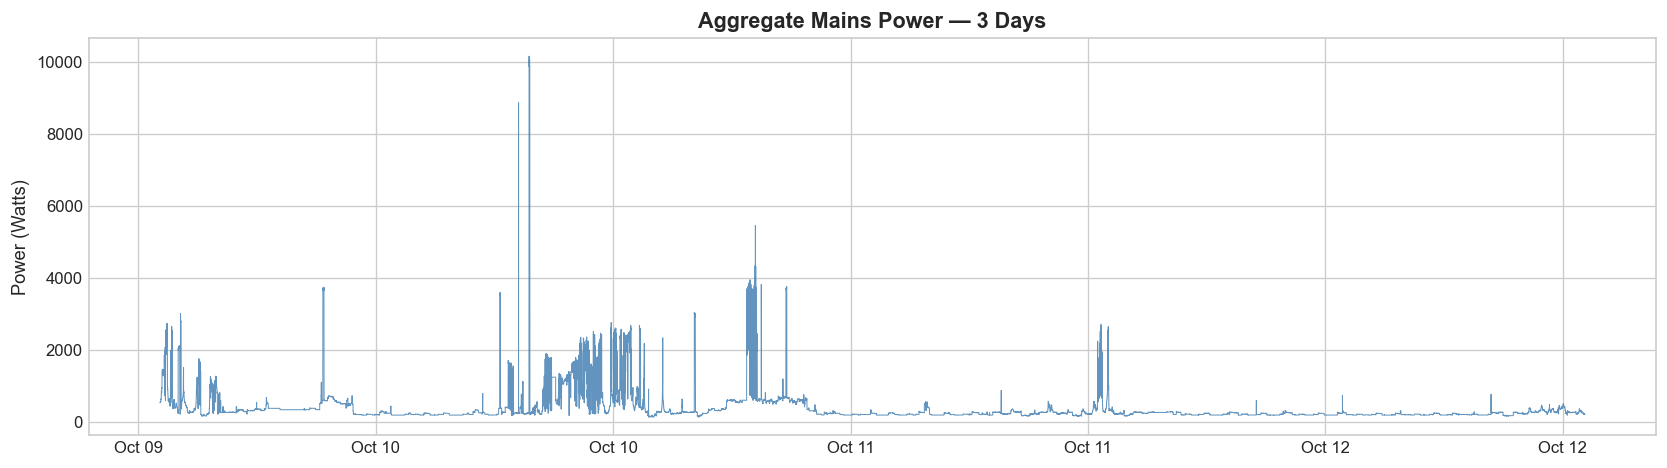

In [8]:
sample = df['mains'].iloc[:3*86400]  # 3 days at 1Hz

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample.index, sample.values, color='steelblue', linewidth=0.6, alpha=0.85)
ax.set_ylabel('Power (Watts)', fontsize=11)
ax.set_title('Aggregate Mains Power — 3 Days', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.savefig('../outputs/01_mains_overview.png', dpi=150)
plt.show()

## My Observations

The aggregate power signal contains a relatively stable baseline with occasional large spikes reaching several kilowatts. While major switching events are clearly visible, it is not possible to determine which appliance caused them from the mains signal alone.

This highlights the core NILM challenge: identifying individual appliances from a single combined power measurement.

## Individual appliance traces

Now look at each appliance in isolation. This is where EE intuition matters:
- **Refrigerator**: cycles on/off periodically — compressor behavior
- **Microwave**: short rectangular high-power pulses
- **Washer/Dryer**: long duration, power varies as wash cycle changes
- **Lighting**: clean step change, very stable steady state


At this stage, the appliance channels are shown using their dataset labels. Even without knowing the exact appliance names, it is clear that different devices exhibit very different power consumption patterns. Some appliances operate in short high-power bursts, while others show periodic cycling or long steady-state operation.

These visual differences are what later feature engineering and classification models will attempt to capture.

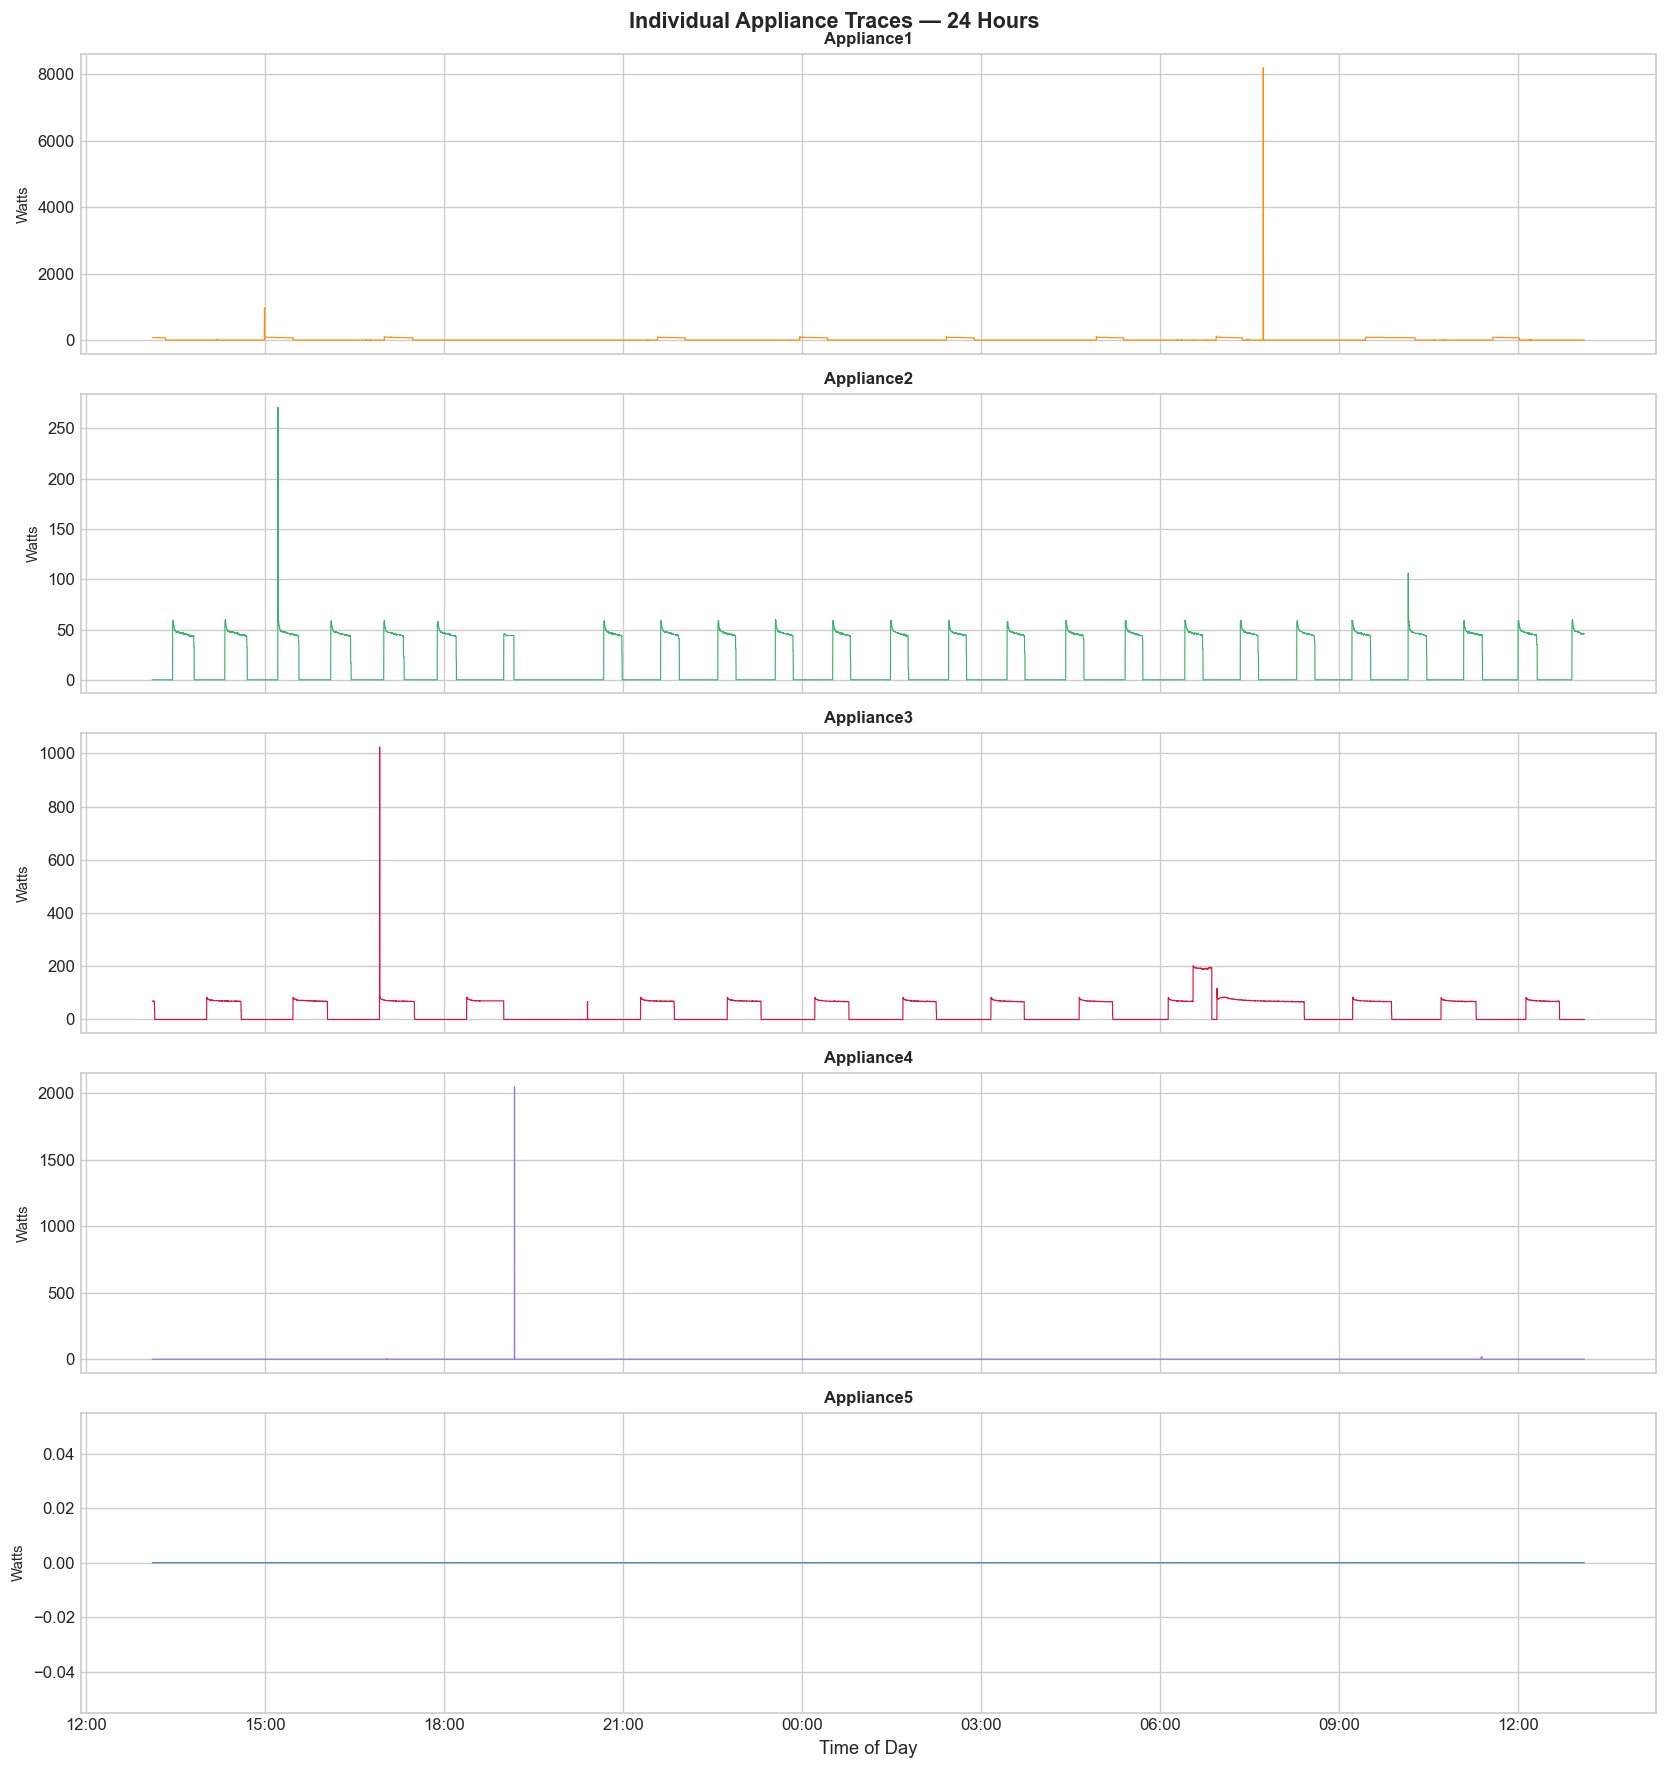

In [9]:
appliances_to_plot = [c for c in df.columns if c != 'mains'][:5]
colors = ['darkorange', 'mediumseagreen', 'crimson', 'mediumpurple', 'steelblue']

fig, axes = plt.subplots(len(appliances_to_plot), 1, figsize=(14, 3*len(appliances_to_plot)), sharex=True)

for ax, col, color in zip(axes, appliances_to_plot, colors):
    data = df[col].iloc[:86400]
    ax.plot(data.index, data.values, color=color, linewidth=0.7)
    ax.set_ylabel('Watts', fontsize=9)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

axes[-1].set_xlabel('Time of Day', fontsize=11)
fig.suptitle('Individual Appliance Traces — 24 Hours', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/01_appliance_traces.png', dpi=150)
plt.show()

 ## My Observations

The appliance traces show that different loads exhibit distinct operating patterns. Appliance2 and Appliance3 display regular cycling behavior, while Appliance1 and Appliance4 are characterized by infrequent but high-power events.

I also noticed that one appliance remained inactive during the selected period, suggesting that some loads contribute only occasionally to household consumption. These differences indicate that power level, event duration, and cycling frequency may be useful features for appliance identification.|

## Energy contribution by appliance

How much does each load contribute to total consumption?
Low-energy appliances are generally harder to identify because their signatures can be masked by larger household loads.

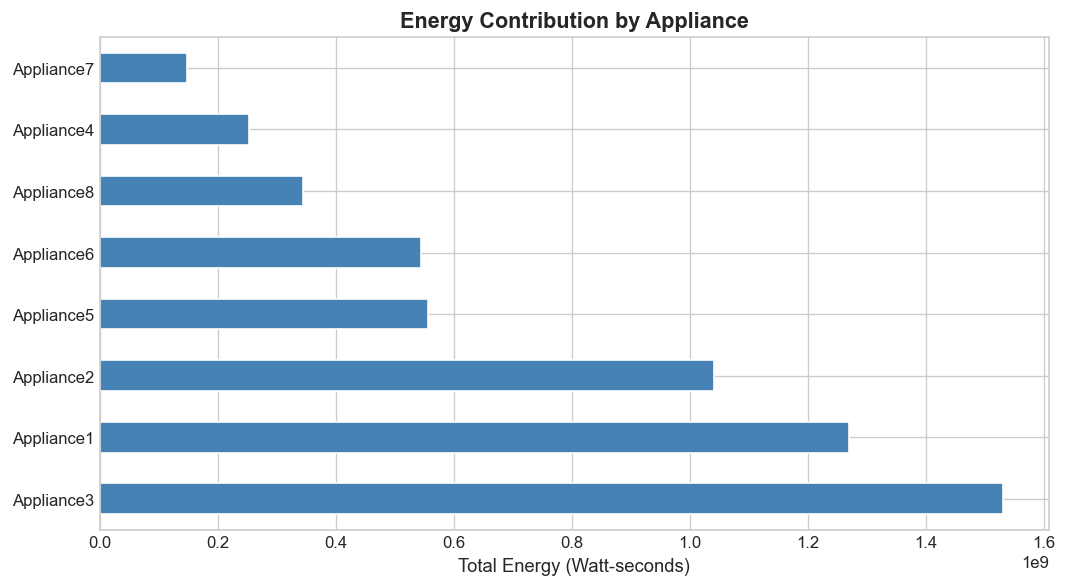

In [10]:
appliance_cols = [c for c in df.columns if c != 'mains']
energy = df[appliance_cols].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
energy.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Total Energy (Watt-seconds)', fontsize=11)
ax.set_title('Energy Contribution by Appliance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/01_energy_contribution.png', dpi=150)
plt.show()

## My Observations

The energy contribution is highly uneven across appliances. A small number of appliances account for most of the household energy consumption, while several others contribute only a small fraction.

This suggests that high-energy appliances may be easier to identify in the aggregate signal because their signatures are more prominent, whereas low-energy appliances are more likely to be masked by larger loads.

In [11]:
# save 7-day sample for downstream notebooks
df_sample = df.iloc[:7*86400]
df_sample.to_csv('../data/processed/house1_7days.csv')
print(f'Saved: {df_sample.shape}')

Saved: (604800, 9)
